In [66]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("../Data/bank-full.csv", sep=';')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df = data.copy()
df.shape

(45211, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [8]:
df['job'] = df['job'].str.rstrip(".")
df['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [9]:
cat_features = df.select_dtypes(include='object').columns
num_features = df.select_dtypes(exclude='object').columns

In [10]:
print(cat_features)
print(num_features)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


continuous features : 'age', 'balance', 'duration'(in sec), 'previous', 'campaign', 'pdays'

categorical features : 'marital', 'education', 'contact', 'poutcome'

binary categorical features : 'default', 'housing', 'loan', 'y'

temporal features : 'month', 'day'

In [11]:
df.describe(exclude='object')

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


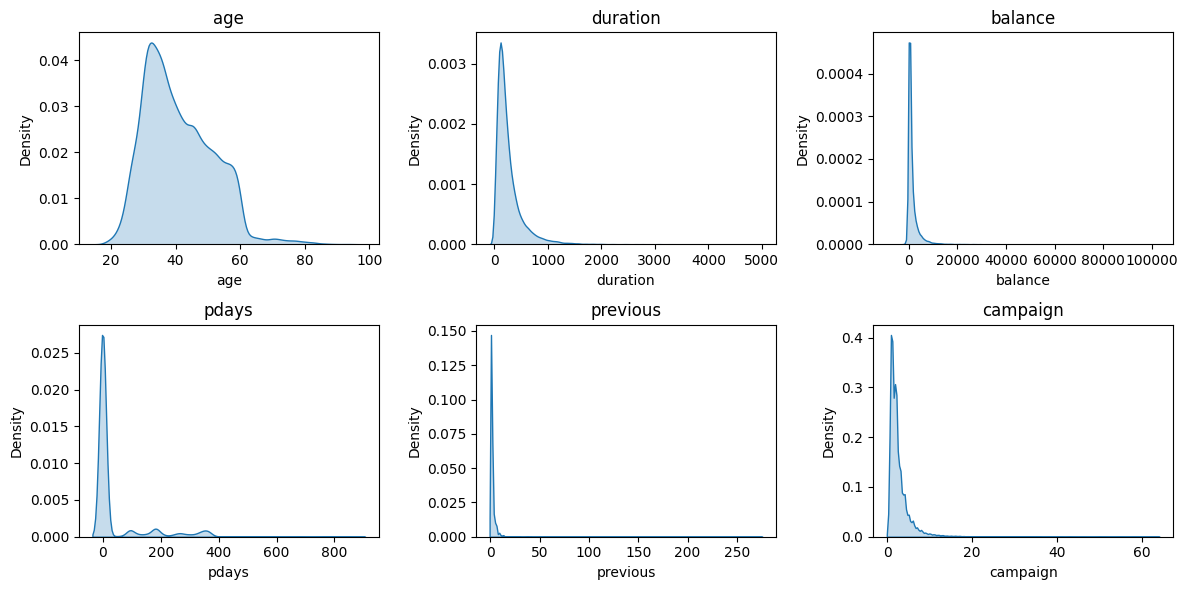

In [12]:
num_cols = ['age', 'duration', 'balance', 'pdays', 'previous', 'campaign']
fig,ax = plt.subplots(2,3, figsize=(12,6))
ax = ax.flatten()

for i,col in enumerate(num_cols):
    sns.kdeplot(df[col], ax=ax[i], fill=True)
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import skew, kurtosis
for col in num_cols:
    print(f'{col}:{skew(df[col])}')

age:0.6847952047866451
duration:3.1442137770103913
balance:8.360030947252687
pdays:2.615628689259389
previous:41.84506608797322
campaign:4.898487638410557


1. age = The distribution of age is positively skewed. Most customers are between 30 and 50 years old, while relatively few customers are older than 70 years. This suggests that this campaign focuses more on middle-age customers.
2. duration = The duration variable is highly positively skewed, indicating that most calls are relatively short, while a small number of calls last much longer.
3. balance = The average account balance is approximately 1,362 euros. The distribution is highly positively skewed, indicating that while most customers have relatively low account balances (including many with a balance close to zero), a small number of customers have exceptionally high balances, which appear as potential outliers.
4. pdays = Since the 25th, 50th, and 75th percentiles are all -1, this indicates that at least 75% of customers had never been contacted in a previous marketing campaign, where -1 represent customers who are not previously contacted. Also the mean of approximately 40 days is influenced by some of the customers who had been contacted previously. 
5. previous = A highly-right skewed feature with sharp peak at zero indicate that majority of customers were not contacted in the previous campaign.
6. campaign = capaign is highly-right skewed with most customers contacted only 1-3 times during the campaign, while relatively very small number of customers were contacted repeatedly resulting in a long tail.

#### Outlier Detection

In [14]:
cols = ['age', 'balance', 'duration', 'campaign']
outlier_summary = {'feature':[], 'lower_bound':[], 'upper_bound':[], 'outliers':[], 'outlier_percentage':[]}
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    #count outliers
    outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]

    #percentage outliers
    outlier_percentage = (len(outliers)/len(df)) * 100
    
    outlier_summary['feature'].append(col)
    outlier_summary['lower_bound'].append(lower_bound)
    outlier_summary['upper_bound'].append(upper_bound)
    outlier_summary['outliers'].append(len(outliers))
    outlier_summary['outlier_percentage'].append(outlier_percentage)

In [15]:
pd.DataFrame(outlier_summary)

,feature,lower_bound,upper_bound,outliers,outlier_percentage
0,age,10.5,70.5,487,1.077171
1,duration,-221.0,643.0,3235,7.155338
2,balance,-1962.0,3462.0,4729,10.459844
3,pdays,-1.0,-1.0,8257,18.263255
4,previous,0.0,0.0,8257,18.263255
5,campaign,-2.0,6.0,3064,6.777112


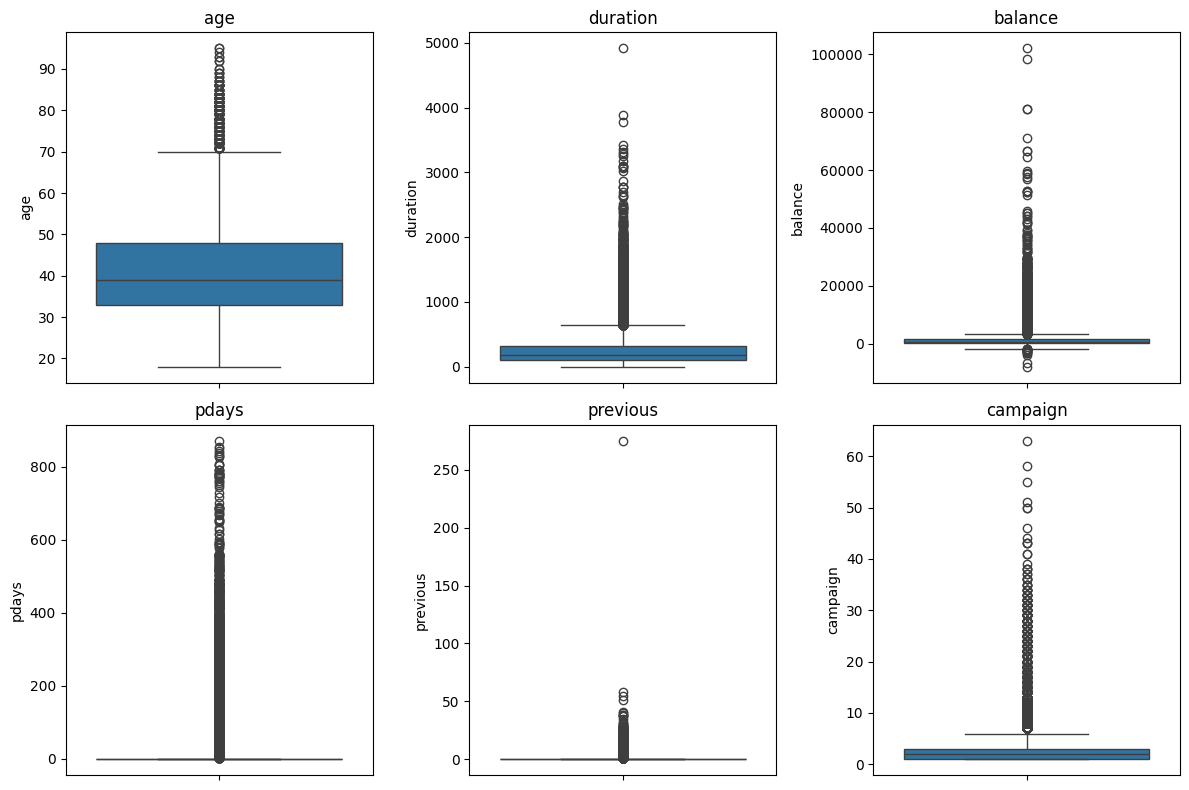

In [16]:
fig,ax = plt.subplots(2,3, figsize=(12,8))
ax = ax.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(df[col], ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

1. age = Most customers are between 30 and 50 years old while relatively small number are older than 70 years. This values are realistic and represent older customers rather than outlier i.e. data erros.
2. balance = Most customers maintain relatively low account balances, while a small number of customers have very high account balances exceeding 60000. These observations appear as outlier but are likely genuine high-value customers. Negative balances might indicate debt.
3. duration = Most customer calls are relatively short. There are several calls that last more than 2000 sec(more than half hour) and appear as outlier. These longer calls may indicate higher customer engagement and are most likely valid observations.
4. campaign = Majority of customers were contacted 1 to 3 times during the campaign, while a small number of customers were contacted many more times, resulting in several upper outliers. These outliers are not data errors they might be potential customers.

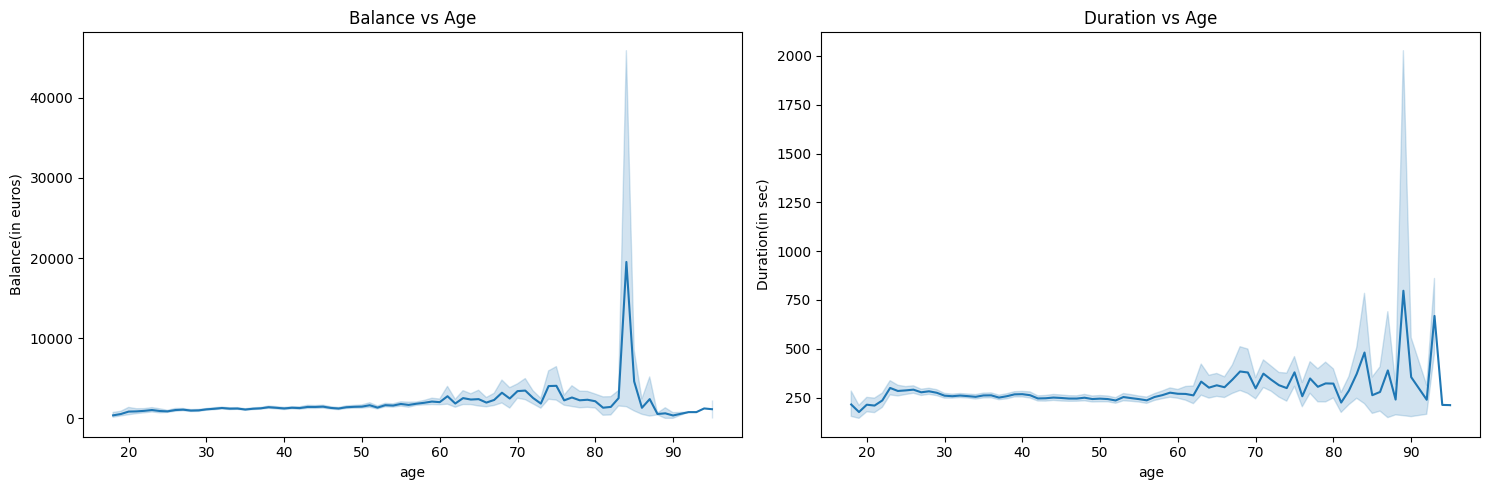

In [17]:
fig,ax = plt.subplots(1,2,figsize=(15,5))
ax = ax.flatten()

sns.lineplot(data=df, x='age', y='balance', ax=ax[0])
ax[0].set_xlabel('age')
ax[0].set_ylabel('Balance(in euros)')
ax[0].set_title('Balance vs Age')


sns.lineplot(data=df, x='age', y='duration', ax=ax[1])
ax[1].set_xlabel('age')
ax[1].set_ylabel('Duration(in sec)')
ax[1].set_title('Duration vs Age')

plt.tight_layout()
plt.show()

The average account balance tends to increase with age, with customers above 60 years generally having higher balances. A sharp increase is observed among customers aged around 80 to 85 years. However, there are relatively few customers in this aged group and the wider confidence interval suggest that there is greater variability and uncertanity in the estimated mean balance in this group. We cannot conclude that all customers from this age group have high account balance. 


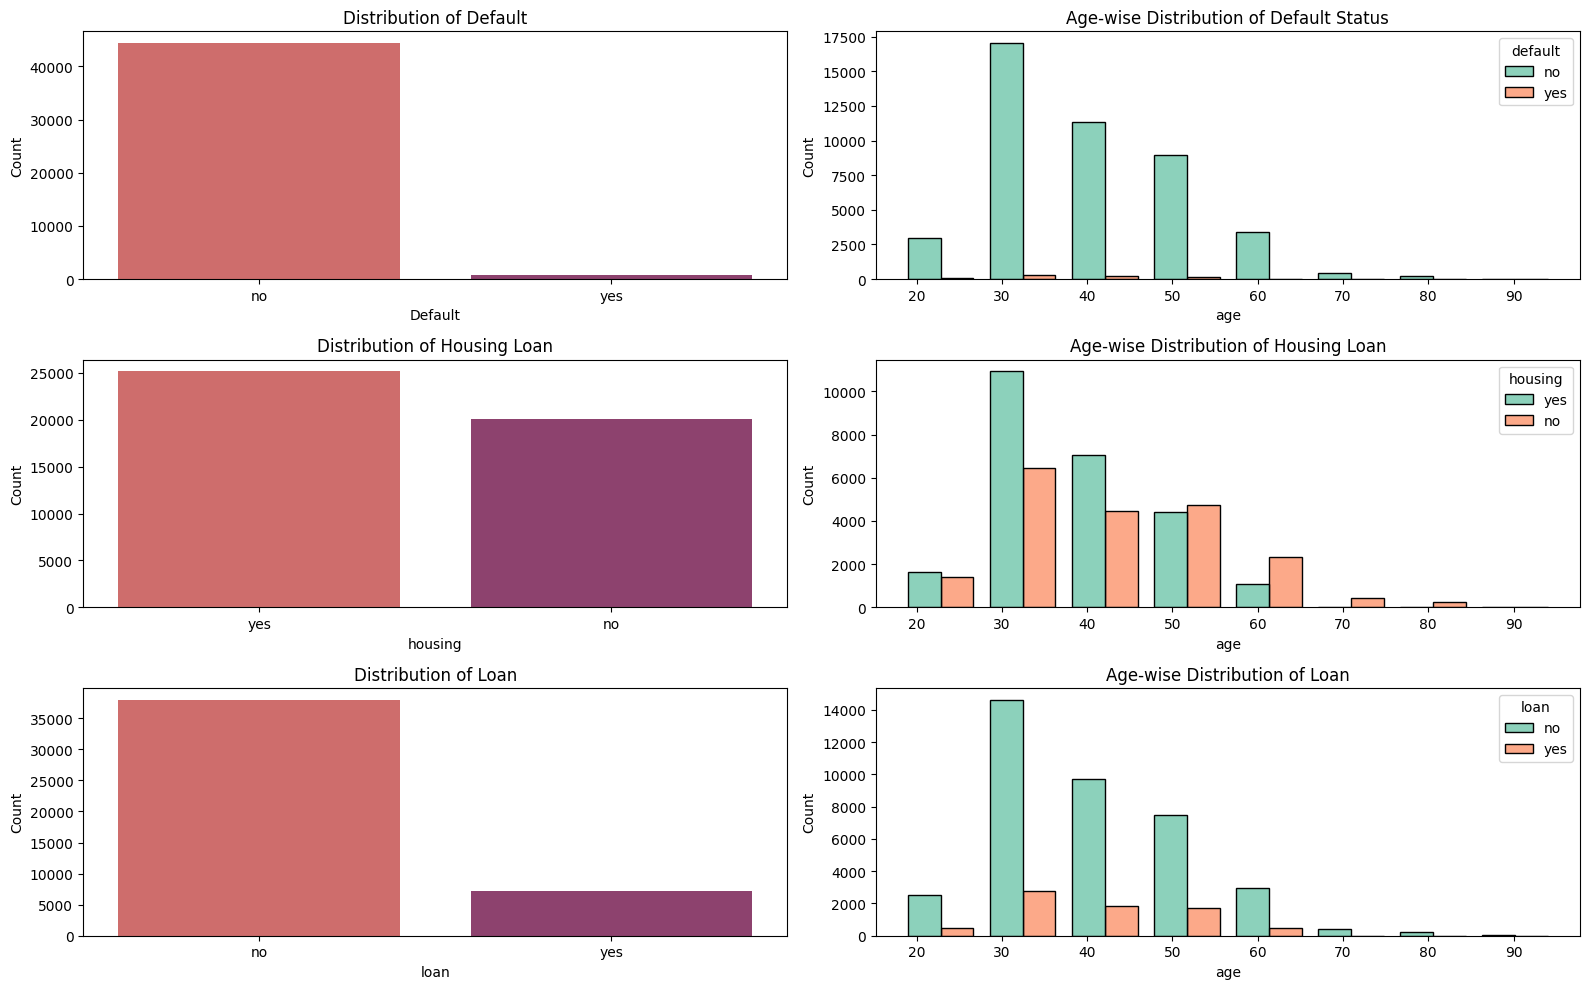

In [18]:
fig,ax = plt.subplots(3,2, figsize=(16,10))

sns.countplot(x='default', data=df, palette='flare', ax=ax[0,0])
ax[0,0].set_xlabel('Default')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Distribution of Default')

sns.histplot(x='age', hue='default', data=df, multiple="dodge", shrink=.8, binwidth=10, palette='Set2', ax=ax[0,1])
ax[0,1].set_xlabel('age')
ax[0,1].set_title('Age-wise Distribution of Default Status')

sns.countplot(x='housing', data=df, palette='flare', ax=ax[1,0])
ax[1,0].set_xlabel('housing')
ax[1,0].set_ylabel('Count')
ax[1,0].set_title('Distribution of Housing Loan')

sns.histplot(x='age', hue='housing', data=df, multiple="dodge", shrink=.8, binwidth=10, palette='Set2', ax=ax[1,1])
ax[1,1].set_xlabel('age')
ax[1,1].set_title('Age-wise Distribution of Housing Loan')

sns.countplot(x='loan', data=df, palette='flare', ax=ax[2,0])
ax[2,0].set_xlabel('loan')
ax[2,0].set_ylabel('Count')
ax[2,0].set_title('Distribution of Loan')

sns.histplot(x='age', hue='loan', data=df, multiple="dodge", shrink=.8, binwidth=10, palette='Set2', ax=ax[2,1])
ax[2,1].set_xlabel('age')
ax[2,1].set_title('Age-wise Distribution of Loan')

plt.tight_layout()
plt.show()


Around 50–60% of customers have a home loan, and most of them are 30–50 years old.
After the age of 50, the number of customers without a home loan becomes higher than those with a home loan.
The highest number of defaulters are in the 30–40 years age group.
Only a small number of customers have a personal loan, with the highest count also in the 30–40 years age group.

In [19]:
pd.crosstab([df['loan'], df['housing']], df['y'])

y                no   yes
loan housing             
no   no       14069  3135
     yes      19093  1670
yes  no        2658   219
     yes       4102   265

Customers with no loan are most likely to subscribe to a term deposit. 
Very few customers have both loans(personal and home loan) and only a small number of them have susbcribed to a term deposit.

We can create a new feature called 'Debt' to indicate whether a customer has any loan or not.

In [20]:
pd.crosstab(df['default'], [df['loan'], df['housing']])

loan        no          yes      
housing     no    yes    no   yes
default                          
no       16992  20461  2709  4234
yes        212    302   168   133

Customers with a home loan have the highest number of defaulters. Also, there are 212 customers who do not have a home loan or personal loan but still have a credit default history. They might have defaulted on another type of credit that we have not considered.

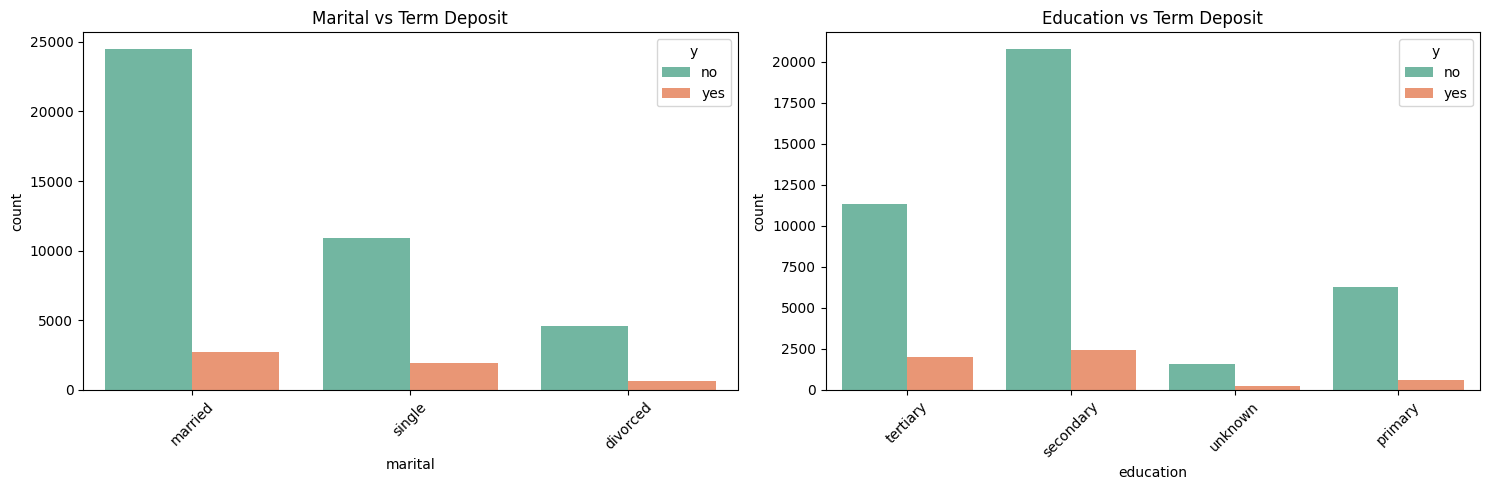

In [21]:
features = ['marital', 'education']
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = ax.flatten()

for i, feature in enumerate(features):
    sns.countplot(x=feature, hue='y', data=df, ax=ax[i], palette='Set2')
    ax[i].set_title(f'{feature.capitalize()} vs Term Deposit')
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [22]:
pd.crosstab(df['poutcome'], df['y'], normalize='index').mul(100).round(1)

y,no,yes
poutcome,,
failure,87.4,12.6
other,83.3,16.7
success,35.3,64.7
unknown,90.8,9.2


For about 90% of customers, the previous campaign outcome is unknown, and only a small proportion subscribed to the term deposit.
Customers with a previous campaign outcome of failure or other are less likely to subscribe to a term deposit.

In [23]:
## Creating new feature 'Debt(Home/Personal)'
df['Debt(Home/Personal)'] = np.where((df['loan'] == 'no') & (df['housing'] == 'no'), 'no', 'yes')

In [24]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Debt(Home/Personal)
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,yes
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,yes


In [25]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

The dataset is highly imbalanced, with about 88% of customers not subscribing to the term deposit. Here, majority class is 'no' and minority class is 'yes'.
Therefore, imbalance data handling techniques should be applied before training classification models.

<Axes: xlabel='education', ylabel='count'>

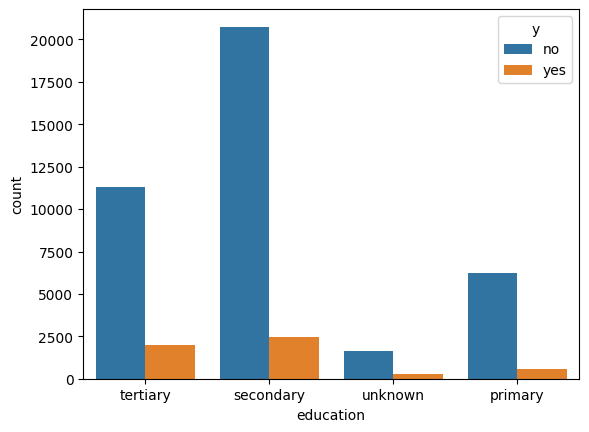

In [26]:
sns.countplot(x='education', hue='y', data=df)

In [27]:
pd.crosstab(df['education'], df['y'])

y,no,yes
education,,
primary,6260,591
secondary,20752,2450
tertiary,11305,1996
unknown,1605,252


In [28]:
## chi-square test
from scipy.stats import chi2_contingency
features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'Debt(Home/Personal)']
summary = {'chi2': [], 'p-value': [], 'Cramers_V': []}
for col in features:
    table = pd.crosstab(df[col], df['y'])
    chi, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    cramer_V = np.sqrt(chi/(n*((min(table.shape) - 1)))) if min(table.shape) > 1 else 0
    summary['chi2'].append(chi)
    summary['p-value'].append(p)
    summary['Cramers_V'].append(cramer_V)

summary_df = pd.DataFrame(summary, index=features).sort_values(by='Cramers_V', ascending=False)
summary_df

,chi2,p-value,Cramers_V
poutcome,4391.506589,0.000000e+00,0.311663
Debt(Home/Personal),1143.282774,1.293553e-250,0.159021
contact,1035.714225,1.251738e-225,0.151355
housing,874.822449,2.918798e-192,0.139103
job,836.105488,3.337122e-172,0.135990
education,238.923506,1.626656e-51,0.072695
loan,209.616980,1.665061e-47,0.068091
marital,196.495946,2.145100e-43,0.065926
default,22.202250,2.453861e-06,0.022160


In [29]:
def interpret(p,v):
    if p < 0.5:
            if v < 0.5:
                return 'sig/weak'
            elif 0.5 <= v < 1:
                 return 'sig/moderate'
            else:
                 return 'sig/strong'
    else:
        if v < 0.5:
                return 'insig/weak'
        elif 0.5 <= v < 1:
                return 'insig/moderate'
        else:
                return 'insig/strong'

In [30]:
summary_df['sig/strength'] = summary_df.apply(lambda row: interpret(row['p-value'] , row['Cramers_V']), axis=1)
summary_df

,chi2,p-value,Cramers_V,sig/strength
poutcome,4391.506589,0.000000e+00,0.311663,sig/weak
Debt(Home/Personal),1143.282774,1.293553e-250,0.159021,sig/weak
contact,1035.714225,1.251738e-225,0.151355,sig/weak
housing,874.822449,2.918798e-192,0.139103,sig/weak
job,836.105488,3.337122e-172,0.135990,sig/weak
education,238.923506,1.626656e-51,0.072695,sig/weak
loan,209.616980,1.665061e-47,0.068091,sig/weak
marital,196.495946,2.145100e-43,0.065926,sig/weak
default,22.202250,2.453861e-06,0.022160,sig/weak


All categorical features showed a statistically significant association with target variable('y'). However, Cramer's V value indicated that these associations are weak. With large datasets, even a small difference between categories can produce very small p-value. This makes test statistically significant.

#### Preprocessing

In [31]:
X = df.drop('y', axis=1)
y = df['y']

In [32]:
X.shape, y.shape

((45211, 17), (45211,))

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
X_train.shape, X_test.shape

((31647, 17), (13564, 17))

In [35]:
continuous_features = ['age', 'previous', 'campaign', 'day','duration', 'balance', 'pdays']
categorical_features = ['marital', 'contact', 'poutcome', 'month', 'job', 'default', 'housing', 'loan', 'Debt(Home/Personal)']
ordinal_features = ['education']
skewed_features = ['duration', 'balance', 'pdays']

In [36]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder,StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [37]:
pt = PowerTransformer(method='yeo-johnson')

preprocessor_1 = ColumnTransformer(transformers=[
    ('skewed', pt, skewed_features),
    ('num', StandardScaler(), continuous_features),
    ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('ordinal', OrdinalEncoder(categories=[['unknown', 'primary', 'secondary', 'tertiary']]), ordinal_features)
])

le = LabelEncoder()

In [38]:
pipeline = Pipeline([
    ('preprocessor', preprocessor_1)
])

In [39]:
a+b

NameError: name 'a' is not defined

1. include bayes classifiers
2. change model training approach(create functions)
3. save results to df to make comparison
4. try SMOTE

In [40]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

#### Baseline Model(Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train_processed, y_train_processed)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import classification_report
y_pred = lr.predict(X_test_processed)
print("Accuracy score: ", accuracy_score(y_test_processed, y_pred))
print("Precision score: ", precision_score(y_test_processed, y_pred))
print("Recall score: ", recall_score(y_test_processed, y_pred))
print("classification report: ")
print(classification_report(y_test_processed, y_pred))

Accuracy score:  0.9018726039516367
Precision score:  0.6539792387543253
Recall score:  0.3548185231539424
classification report: 
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     11966
           1       0.65      0.35      0.46      1598

    accuracy                           0.90     13564
   macro avg       0.79      0.66      0.70     13564
weighted avg       0.89      0.90      0.89     13564



In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test_processed, y_pred))

[[11666   300]
 [ 1031   567]]


In [ ]:
le.classes_

array(['no', 'yes'], dtype=object)

Overall accuracy is 90%. Since our data is highly imbalanced, accuracy is not a reliable metric. The model perform very well on majority class('no'), correctly identifying 98% non-subscribers. But model performs poorly  on the minority class('yes'). A recall of 36% indicate model was not able to classify subscribers correctly. A low f1 score(47%) for the minority class confirms that the model is not detecting potential subscribers correctly. Hence, model is biased toward the majority class('no').

#### SMOTE

In [ ]:
from imblearn.over_sampling import SMOTENC  
smote = SMOTENC(categorical_features = [1, 2, 3, 4, 6, 7, 8, 10, 15, 16], random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
X_train_resampled = pipeline.fit_transform(X_resampled)
X_test_resampled = pipeline.transform(X_test)
y_train_resampled = le.fit_transform(y_resampled)
y_test_resampled = le.transform(y_test)

In [ ]:
lr.fit(X_train_resampled, y_train_resampled)
y_pred = lr.predict(X_test_resampled)
print("Accuracy Score: ", accuracy_score(y_test_resampled, y_pred))
print("Precision score: ", precision_score(y_test_processed, y_pred))
print("Recall score: ", recall_score(y_test_processed, y_pred))
print("classification report: ")
print(classification_report(y_test_resampled, y_pred))

Accuracy Score:  0.8482748451784135
Precision score:  0.4191279887482419
Recall score:  0.7459324155193993
classification report: 
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     11966
           1       0.42      0.75      0.54      1598

    accuracy                           0.85     13564
   macro avg       0.69      0.80      0.72     13564
weighted avg       0.90      0.85      0.87     13564



In [ ]:
print(confusion_matrix(y_test_resampled, y_pred))

[[10314  1652]
 [  406  1192]]


#### Using Cost-Sensitive Learning(penalizes for minority class errors)

In [ ]:
## class weight = 'balanced' assigns a larger weight to the minority class and smaller weight to the majority class based on their frequencies
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_processed, y_train_processed)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test_processed)
print("Accuracy Score: ", accuracy_score(y_test_processed, y_pred))
print("Precision score: ", precision_score(y_test_processed, y_pred))
print("Recall score: ", recall_score(y_test_processed, y_pred))
print("classification report: ")
print(classification_report(y_test_processed, y_pred))

Accuracy Score:  0.8305809495723975
Precision score:  0.39663319551092735
Recall score:  0.8404255319148937
classification report: 
              precision    recall  f1-score   support

           0       0.97      0.83      0.90     11966
           1       0.40      0.84      0.54      1598

    accuracy                           0.83     13564
   macro avg       0.69      0.83      0.72     13564
weighted avg       0.91      0.83      0.85     13564



In [ ]:
print(confusion_matrix(y_test_processed, y_pred))

[[9923 2043]
 [ 255 1343]]


Using Cost-Sensitive learning method which penalizes to minority class errors, recall for minority class increaes indicating model is classifying potential subscribers correctly. But f1 score for minority class is still very low model confirms that model is still biased towards majority class.

Logistic Regression:
[[11666   300]
 [ 1031   567]]
high FN, classifing many potential susbcribers as non-subscribers

SMOTENC:
[[10314  1652]
 [  406  1192]]
high FP, aggresively classifying non-subscribers as subscribers

CSL:
[[9923 2043]
 [ 255 1343]]
high FP, aggresively classifying non-subscribers as subscribers

In [ ]:
models = {
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'SVC': SVC(class_weight='balanced'),
    'lightgbm': LGBMClassifier(class_weight='balanced')
}

In [41]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score, confusion_matrix

In [43]:
def train_classifier(model, X_train, y_train, X_test, y_test, sample_weights=None):
    if sample_weights is not None:
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    return accuracy, precision, recall

In [44]:
def evaluate_model(true, pred):
    accuracy = accuracy_score(true, pred)
    precision = precision_score(true, pred, average='binary')
    recall = recall_score(true, pred, average='binary')
    f1 = f1_score(true, pred, average='binary')

    return accuracy, precision, recall, f1

In [45]:
def plot_pr_curves(
    models,
    X_train,
    y_train,
    X_test,
    y_test,
    sample_weights=None,
    title='PR-Curve',
    min_precision=0.40
):
    
    results = []
    plt.figure(figsize=(12, 8))

    for name, model in models.items():

        if sample_weights is not None:
            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weights
            )
        else:
            model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        precision, recall, thresholds = precision_recall_curve(
            y_test,
            y_prob
        )

        ap = average_precision_score(y_test, y_prob)

        valid = precision[:-1] >= min_precision

        if valid.any():

            valid_indices = np.where(valid)[0]

            best_idx = valid_indices[
                np.argmax(recall[:-1][valid])
            ]

            max_recall = recall[best_idx]
            best_precision = precision[best_idx]
            best_threshold = thresholds[best_idx]

        else:
            max_recall = 0
            best_precision = 0
            best_threshold = np.nan

        results.append({
            'Model': name,
            'Threshold': best_threshold,
            'Precision': best_precision,
            'Recall': max_recall,
            'AP': ap
        })

        plt.plot(
            recall,
            precision,
            label=f"{name} (AP={ap:.3f})"
        )

    plt.axhline(
        y=min_precision,
        linestyle='--',
        label=f'Min Precision = {min_precision:.0%}'
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        'Recall',
        ascending=False
    )

#### SMOTE

In [ ]:
from imblearn.over_sampling import SMOTENC  
smote = SMOTENC(categorical_features = [1, 2, 3, 4, 6, 7, 8, 10, 15, 16], random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
X_train_resampled = pipeline.fit_transform(X_resampled)
X_test_resampled = pipeline.transform(X_test)
y_train_resampled = le.fit_transform(y_resampled)
y_test_resampled = le.transform(y_test)

In [ ]:
models = {
    'RandomForest' : RandomForestClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42),
    'BernoulliNB' : BernoulliNB()
}

In [ ]:
perf_smote = {'model': [], 'accuracy_score': [], 'precision_score': [], 'recall_score': []}

for name, model in models.items():
    accuracy, precision, recall = train_classifier(model, X_train_resampled, y_train_resampled, X_test_resampled, y_test_resampled)
    perf_smote['model'].append(name)
    perf_smote['accuracy_score'].append(accuracy)
    perf_smote['precision_score'].append(precision)
    perf_smote['recall_score'].append(recall)

KeyboardInterrupt: 

In [ ]:
perf_smote_df = pd.DataFrame(perf_smote)
perf_smote_df.sort_values(by='precision_score', ascending=False)

,model,accuracy_score,precision_score,recall_score
0,RandomForest,0.885137,0.508929,0.713392
8,ExtraTrees,0.883220,0.503247,0.678974
7,Bagging,0.882704,0.501717,0.640175
6,XGBoost,0.882483,0.500887,0.707134
5,SVM,0.868844,0.465810,0.771589
1,GradientBoost,0.856385,0.439530,0.795995
4,KNN,0.855500,0.432513,0.725907
2,AdaBoost,0.855352,0.432442,0.729036
3,DecisionTree,0.850634,0.407917,0.593242
9,BernoulliNB,0.783692,0.308815,0.675219


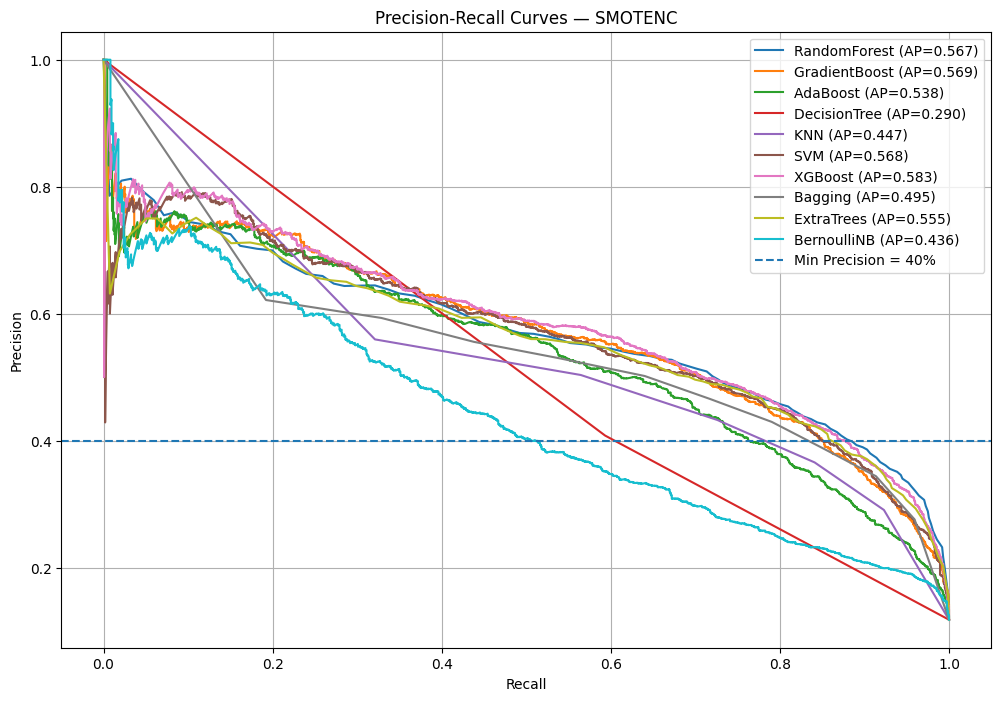

,Model,Max Recall @ Precision >= 40%,AP
0,RandomForest,0.879224,0.567086
6,XGBoost,0.876721,0.583165
8,ExtraTrees,0.857947,0.555182
1,GradientBoost,0.850438,0.569166
5,SVM,0.850438,0.568034
7,Bagging,0.790363,0.495126
2,AdaBoost,0.762203,0.538142
4,KNN,0.725907,0.446949
3,DecisionTree,0.593242,0.289915
9,BernoulliNB,0.510638,0.436079


In [ ]:
## Does not include KNN
plot_pr_curves(models, X_train_resampled, y_train_resampled, X_test_resampled, y_test_resampled, title="Precision-Recall Curves — SMOTENC",  min_precision=0.40)

#### Cost-Sensitive learning(sample weights)

In [ ]:
models = {
    'RandomForest' : RandomForestClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42),
    'BernoulliNB' : BernoulliNB()
}

In [ ]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

In [ ]:
sample_weights = np.where(
    y_train_processed == 1,
    (y_train_processed == 0).sum() / (y_train_processed == 1).sum(),
    1
)

In [ ]:
perf_csl = {'model': [], 'accuracy_score': [], 'precision_score': [], 'recall_score': []}

for name, model in models.items():
    accuracy, precision, recall = train_classifier(model, X_train_processed, y_train_processed, X_test_processed, y_test_processed, sample_weights=sample_weights)
    perf_csl['model'].append(name)
    perf_csl['accuracy_score'].append(accuracy)
    perf_csl['precision_score'].append(precision)
    perf_csl['recall_score'].append(recall)

In [ ]:
perf_csl_df = pd.DataFrame(perf_csl)
perf_csl_df.sort_values(by='precision_score', ascending=False)

,model,accuracy_score,precision_score,recall_score
0,RandomForest,0.903789,0.665537,0.368586
7,ExtraTrees,0.903642,0.652997,0.388611
6,Bagging,0.894795,0.590285,0.349812
5,XGBoost,0.878133,0.489476,0.800375
3,DecisionTree,0.873341,0.461140,0.445557
4,SVM,0.851740,0.435610,0.874218
2,AdaBoost,0.846874,0.422417,0.816020
1,GradientBoost,0.841418,0.416892,0.867960
8,BernoulliNB,0.767325,0.293149,0.690864


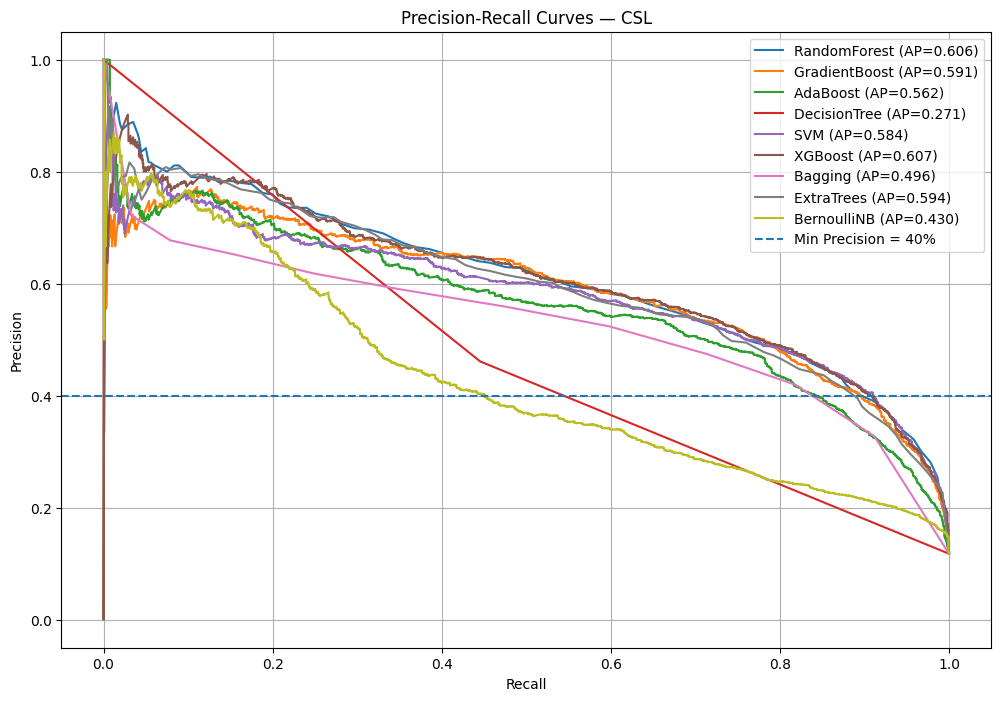

,Technique,Model,Threshold,Precision,Recall,AP
4,Precision-Recall Curves — CSL,SVM,0.098495,0.400055,0.910513,0.584146
5,Precision-Recall Curves — CSL,XGBoost,0.243910,0.400055,0.908010,0.607253
0,Precision-Recall Curves — CSL,RandomForest,0.120000,0.400280,0.895494,0.606281
1,Precision-Recall Curves — CSL,GradientBoost,0.458429,0.400056,0.895494,0.590791
7,Precision-Recall Curves — CSL,ExtraTrees,0.130000,0.406106,0.882353,0.594165
2,Precision-Recall Curves — CSL,AdaBoost,0.499145,0.400000,0.843554,0.562469
6,Precision-Recall Curves — CSL,Bagging,0.200000,0.419365,0.818523,0.496372
8,Precision-Recall Curves — CSL,BernoulliNB,0.898071,0.400111,0.451189,0.430096
3,Precision-Recall Curves — CSL,DecisionTree,1.000000,0.461140,0.445557,0.270784


In [ ]:
plot_pr_curves(models, X_train_processed, y_train_processed, X_test_processed, y_test_processed, title="Precision-Recall Curves — CSL", sample_weights=sample_weights, min_precision=0.40)

#### SMOTENC + Cost-Sensitive Learning(sample weights)

In [ ]:
ratio = (y_train_processed == 0).sum() / (y_train_processed == 1).sum()
sample_weights = np.where(
    y_train_resampled == 1,
    ratio,
    1
)

NameError: name 'y_train_resampled' is not defined

In [ ]:
perf_smote_csl = {'model': [], 'accuracy_score': [], 'precision_score': [], 'recall_score': []}
for name,model in models.items():
    accuracy, precision, recall = train_classifier(model, X_train_resampled, y_train_resampled, X_test_resampled, y_test_resampled, sample_weights=sample_weights)
    perf_smote_csl['model'].append(name)
    perf_smote_csl['accuracy_score'].append(accuracy)
    perf_smote_csl['precision_score'].append(precision)
    perf_smote_csl['recall_score'].append(recall)

In [ ]:
perf_smote_csl_df = pd.DataFrame(perf_smote_csl)
perf_smote_csl_df

,model,accuracy_score,precision_score,recall_score
0,RandomForest,0.883736,0.504988,0.665207
1,GradientBoost,0.690799,0.270103,0.954318
2,AdaBoost,0.638676,0.239470,0.949937
3,DecisionTree,0.856901,0.424615,0.604506
4,SVM,0.752949,0.315201,0.935544
5,XGBoost,0.821660,0.386571,0.875469
6,Bagging,0.877838,0.485003,0.596996
7,ExtraTrees,0.885137,0.509643,0.661452
8,BernoulliNB,0.619950,0.219612,0.871715


In [ ]:
perf_smote_csl_df.merge(perf_csl_df, on='model', how='left').merge(perf_smote_df, on='model', how='left')

,model,accuracy_score_x,precision_score_x,recall_score_x,accuracy_score_y,precision_score_y,recall_score_y,accuracy_score,precision_score,recall_score
0,RandomForest,0.883736,0.504988,0.665207,0.903789,0.665537,0.368586,0.885137,0.508929,0.713392
1,GradientBoost,0.690799,0.270103,0.954318,0.841418,0.416892,0.867960,0.856385,0.439530,0.795995
2,AdaBoost,0.638676,0.239470,0.949937,0.846874,0.422417,0.816020,0.855352,0.432442,0.729036
3,DecisionTree,0.856901,0.424615,0.604506,0.873341,0.461140,0.445557,0.850634,0.407917,0.593242
4,SVM,0.752949,0.315201,0.935544,0.851740,0.435610,0.874218,0.868844,0.465810,0.771589
5,XGBoost,0.821660,0.386571,0.875469,0.878133,0.489476,0.800375,0.882483,0.500887,0.707134
6,Bagging,0.877838,0.485003,0.596996,0.894795,0.590285,0.349812,0.882704,0.501717,0.640175
7,ExtraTrees,0.885137,0.509643,0.661452,0.903642,0.652997,0.388611,0.883220,0.503247,0.678974
8,BernoulliNB,0.619950,0.219612,0.871715,0.767325,0.293149,0.690864,0.783692,0.308815,0.675219


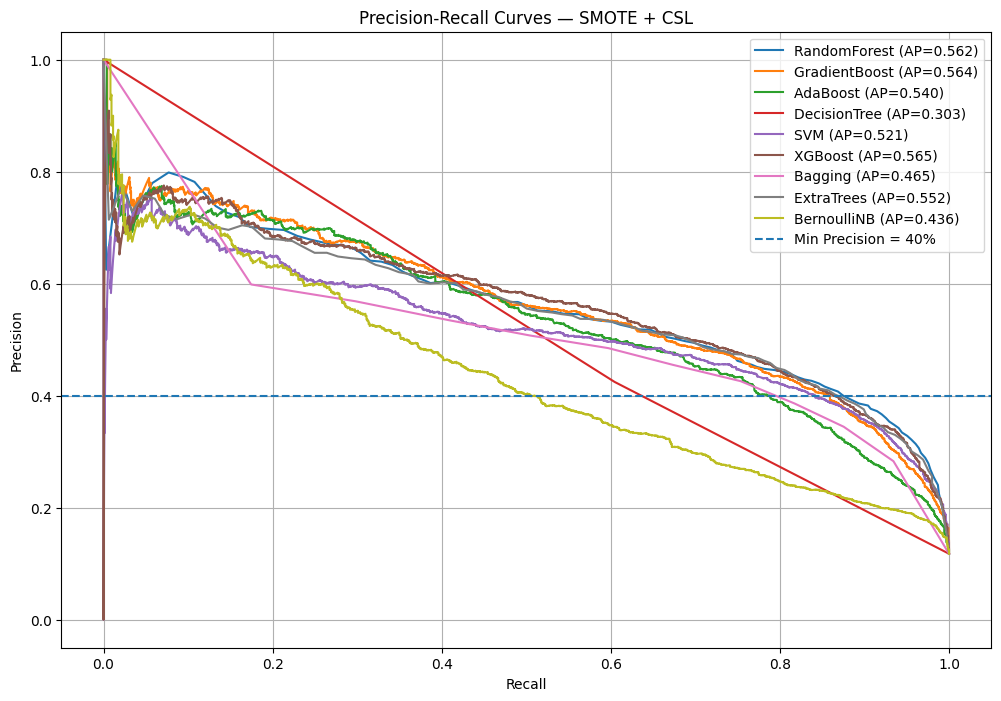

,Model,Threshold,Precision,Recall,AP
0,RandomForest,0.270000,0.400746,0.874218,0.561608
7,ExtraTrees,0.280000,0.402329,0.864831,0.551997
5,XGBoost,0.549051,0.400000,0.863579,0.564892
1,GradientBoost,0.842002,0.400000,0.857322,0.564013
4,SVM,0.364601,0.400059,0.841677,0.520531
2,AdaBoost,0.508655,0.400254,0.788486,0.540073
6,Bagging,0.400000,0.426044,0.753442,0.465363
3,DecisionTree,1.000000,0.424615,0.604506,0.303276
8,BernoulliNB,0.974687,0.400000,0.509387,0.436074


In [ ]:
plot_pr_curves(models, X_train_resampled, y_train_resampled, X_test_resampled, y_test_resampled, title="Precision-Recall Curves — SMOTE + CSL", sample_weights=sample_weights, min_precision=0.40)

In [ ]:
perf_smote_csl_df.sort_values(by='recall_score', ascending=False).merge(perf_csl_df.sort_values(by='recall_score', ascending=False), on='model', how='left').merge(perf_smote_df.sort_values(by='recall_score', ascending=False), on='model', how='left')

,model,accuracy_score_x,precision_score_x,recall_score_x,accuracy_score_y,precision_score_y,recall_score_y,accuracy_score,precision_score,recall_score
0,GradientBoost,0.690799,0.270103,0.954318,0.841418,0.416892,0.867960,0.856385,0.439530,0.795995
1,AdaBoost,0.638676,0.239470,0.949937,0.846874,0.422417,0.816020,0.855352,0.432442,0.729036
2,SVM,0.752949,0.315201,0.935544,0.851740,0.435610,0.874218,0.868844,0.465810,0.771589
3,XGBoost,0.821660,0.386571,0.875469,0.878133,0.489476,0.800375,0.882483,0.500887,0.707134
4,BernoulliNB,0.619950,0.219612,0.871715,0.767325,0.293149,0.690864,0.783692,0.308815,0.675219
5,RandomForest,0.883736,0.504988,0.665207,0.903789,0.665537,0.368586,0.885137,0.508929,0.713392
6,ExtraTrees,0.885137,0.509643,0.661452,0.903642,0.652997,0.388611,0.883220,0.503247,0.678974
7,DecisionTree,0.856901,0.424615,0.604506,0.873341,0.461140,0.445557,0.850634,0.407917,0.593242
8,Bagging,0.877838,0.485003,0.596996,0.894795,0.590285,0.349812,0.882704,0.501717,0.640175


SMOTE
    Model	        Max Recall @ Precision >= 40%	AP
0	RandomForest	0.879224	                  0.567086
6	XGBoost	        0.876721	                  0.583165
8	ExtraTrees	    0.857947	                  0.555182

CSL
	Model	    Threshold	Precision	Recall	    AP
4	SVM  	    0.098495	0.400055	0.910513	0.584146
5	XGBoost 	0.243910	0.400055	0.908010	0.607253  
0	RandomForest	0.120000	0.400280	0.895494	0.606281  

SMOTE + CSL
    Model	        Threshold	Precision	Recall	    AP
0	RandomForest	0.270000	0.400746	0.874218	0.561608
7	ExtraTrees	    0.280000	0.402329	0.864831	0.551997
5	XGBoost	        0.549051	0.400000	0.863579	0.564892

CSL has achieved the maximum recall at the required precision of 40% and also produced the highest AP among the three imbalanced-handling techniques.
Under CSL, SVM achieved the highest recall (91.05%), while XGBoost achieved the highest AP (0.607). Since, our goal is to maximize recall while maintaining minimu precision of 40%, SVM is the best choice. However, the difference in recall between SVM and XGBoost is small (0.25), while XGBoost has noticeably higher AP. Therefore, both models require further assessment before selecting the final model.

1. compare confusion matrix at the selected threshold
2. Check several precision constraints
3. Check corss-validation (current recall difference could simply due to paritcular train set) - stratified cross validation
4. Check Probability Clibration

In [ ]:
models = {
    'SVM': [SVC(probability=True, random_state=42), 0.098495],
    'XGBoost': [XGBClassifier(random_state=42), 0.243910]
}

for name, model in models.items():
    model[0].fit(X_train_processed, y_train_processed, sample_weight=sample_weights)
    t = model[1]
    y_prob = model[0].predict_proba(X_test_processed)[:, 1]
    y_pred = (y_prob >= t).astype(int)
    print(name)
    print("Recall: {:.4f}".format(recall_score(y_test_processed, y_pred)))
    print("Precison: {:.4f}".format(precision_score(y_test_processed, y_pred)))
    print("Average PR: {:.4f}".format(average_precision_score(y_test_processed, y_prob)))
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_test_processed, y_pred))
    print()

SVM
Recall: 0.9105
Precison: 0.4001
Average PR: 0.5841
Confusion Matrix:
[[9784 2182]
 [ 143 1455]]

XGBoost
Recall: 0.9080
Precison: 0.4001
Average PR: 0.6073
Confusion Matrix:
[[9790 2176]
 [ 147 1451]]



SVM produces slightly more false positives than XGBoost, but the difference is only six observations. Also, SVM produces fewer false negatives, which aligns with our objective of maximizing recall.
Now using Stratified cross validation we futher assess the robustness of these results, to determine whether the performance of SVM over XGBoost remains consistent across different validation set.

#### Stratified Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
def recall_at_precision(y_test, y_prob, min_precision=0.40):
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    valid = precision[:-1] >= min_precision

    if valid.any():
        valid_idx = np.where(valid)[0]
        best_idx = valid_idx[
            np.argmax(recall[:-1][valid])
        ]

        return(
            recall[best_idx],
            precision[best_idx],
            thresholds[best_idx]
        )
    return np.nan, np.nan, np.nan

In [68]:
def evaluate_model_cv(model, X, y, min_precision=0.40):
    recalls = []
    precisions = []
    thresholds = []
    aps = []

    for train_idx, val_idx in skf.split(X,y):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        sample_weights = np.where(
            y_train_fold == 1,
            (y_train_fold == 0).sum()/(y_train_fold == 1).sum(),
            1
        )

        X_train_processed = pipeline.fit_transform(X_train_fold)
        X_val_processed = pipeline.transform(X_val_fold)
        y_train_processed = le.fit_transform(y_train_fold)
        y_val_processed = le.transform(y_val_fold)

        model.fit(X_train_processed, y_train_processed, sample_weight=sample_weights)

        y_prob = model.predict_proba(X_val_processed)[:, 1]

        recall, precision, threshold = recall_at_precision(y_val_processed, y_prob, min_precision)
        ap = average_precision_score(y_val_processed, y_prob)

        recalls.append(recall)
        precisions.append(precision)
        thresholds.append(threshold)
        aps.append(ap)

    results = {
        'Mean Recall': np.nanmean(recalls),
        'Std Recall': np.nanstd(recalls, ddof=1),

        'Mean Precision': np.nanmean(precisions),
        'Std Precision': np.nanstd(precisions, ddof=1),

        'Mean AP': np.mean(aps),
        'Std AP': np.std(aps, ddof=1),

        'Mean Threshold': np.mean(thresholds),
        'Std Threshold': np.std(thresholds, ddof=1)
    }
    results = {key: round(value, 4) for key,value in results.items()}

    return results

In [ ]:
svm_results = evaluate_model_cv(
    SVC(probability=True, random_state=42),
    X_train,
    y_train
)

In [ ]:
svm_results

{'Mean Recall': 0.851254350161905,
 'Std Recall': 0.012430326727078703,
 'Mean Precision': 0.40010251867286595,
 'Std Precision': 5.731503680589576e-05,
 'Mean AP': 0.5870028486249741,
 'Std AP': 0.008735967002917195,
 'Mean Threshold': 0.0806185845964043,
 'Std Threshold': 0.0004464115760759888}

In [ ]:
xgb_results = evaluate_model_cv(
    XGBClassifier(random_state=42),
    X_train,
    y_train
)

In [ ]:
xgb_results

{'Mean Recall': 0.9103,
 'Std Recall': 0.0151,
 'Mean Precision': 0.4,
 'Std Precision': 0.0001,
 'Mean AP': 0.599,
 'Std AP': 0.0065,
 'Mean Threshold': 0.0724,
 'Std Threshold': 0.005}

#### OOF

In [ ]:
def get_oof_predictions(model, x, y):

    oof_prob = np.zeros(len(y))

    for train_idx, val_idx in skf.split(x, y):

        # Split
        X_train_fold = x.iloc[train_idx]
        X_val_fold = x.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Preprocessing
        X_train_processed = pipeline.fit_transform(X_train_fold)
        X_val_processed = pipeline.transform(X_val_fold)

        # Encode target
        y_train_processed = le.fit_transform(y_train_fold)

        # CSL weights
        sample_weights = np.where(
            y_train_processed == 1,
            (y_train_processed == 0).sum() /
            (y_train_processed == 1).sum(),
            1
        )

        # Train
        model.fit(
            X_train_processed,
            y_train_processed,
            sample_weight=sample_weights
        )

        # Predict validation fold
        y_prob = model.predict_proba(
            X_val_processed
        )[:, 1]

        # Store predictions in their original positions
        oof_prob[val_idx] = y_prob

    return oof_prob

In [ ]:
oof_prob = get_oof_predictions(XGBClassifier(random_state=42), X_train, y_train)

In [ ]:
recall, precision, threshold = recall_at_precision(
    y_train_processed,
    oof_prob,
    min_precision=0.40
)

print("Recall:", recall)
print("Precision:", precision)
print("Threshold:", threshold)

Recall: 0.8989433757789217
Precision: 0.4
Threshold: 0.2411879599094391


In [ ]:
model =XGBClassifier(random_state=42)
model.fit(X_train_processed, y_train_processed, sample_weight=sample_weights)
y_prob = model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_prob >= 0.2411).astype(int)
print("Recall: {:.4f}".format(recall_score(y_test_processed, y_pred)))
print("Precison: {:.4f}".format(precision_score(y_test_processed, y_pred)))
print("Average PR: {:.4f}".format(average_precision_score(y_test_processed, y_prob)))
print(f"Confusion Matrix:")
print(confusion_matrix(y_test_processed, y_pred))

Recall: 0.9093
Precison: 0.3991
Average PR: 0.6073
Confusion Matrix:
[[9778 2188]
 [ 145 1453]]


In [ ]:
oof_prob = get_oof_predictions(SVC(probability=True), X_train, y_train)
recall, precision, threshold = recall_at_precision(
    y_train_processed,
    oof_prob,
    min_precision=0.40
)

print("Recall:", recall)
print("Precision:", precision)
print("Threshold:", threshold)

Recall: 0.8951503657545381
Precision: 0.4
Threshold: 0.10643893863627606


In [ ]:
model = SVC(probability=True, random_state=42 )
model.fit(X_train_processed, y_train_processed, sample_weight=sample_weights)
y_prob = model.predict_proba(X_test_processed)[:, 1]
y_pred = (y_prob >= 0.1064).astype(int)
print("Recall: {:.4f}".format(recall_score(y_test_processed, y_pred)))
print("Precison: {:.4f}".format(precision_score(y_test_processed, y_pred)))
print("Average PR: {:.4f}".format(average_precision_score(y_test_processed, y_prob)))
print(f"Confusion Matrix:")
print(confusion_matrix(y_test_processed, y_pred))

Recall: 0.9011
Precison: 0.4093
Average PR: 0.5841
Confusion Matrix:
[[9888 2078]
 [ 158 1440]]


Stratified K-Fold CV
        ↓
Train model on each fold
        ↓
Generate OOF probabilities
        ↓
Evaluate OOF performance
        ↓
Select threshold
        ↓
Compare models
        ↓
Select best model
        ↓
Bootstrap OOF predictions
        ↓
95% CI for Recall / AP / Precision
        ↓
Retrain best model on full training data
        ↓
Evaluate ONCE on untouched test set
        ↓
Bootstrap test predictions
        ↓
95% CI for final test performance

#### Scenario 1 - contacting non-subscribers is inexpensive, low precision may be acceptable. We have to maximize recall.

Since, the primary objective was to maximize recall while maintaining minimum precision of approximately 40%, Precision-Recall curve were used for threshold selection.
XGBoost shows highest Recall with threshold 0.2411 subject to precision approximately 40%. Also, XGBoost shows highest Average Precision-Recall.

In [46]:
test_data = pd.read_csv('../Data/bank.csv', sep=';')
test_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [50]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Debt(Home/Personal)
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,yes
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,yes


In [48]:
test_data.shape

(4521, 17)

In [51]:
val_data = test_data.copy()

In [52]:
val_data['Debt(Home/Personal)'] = np.where((val_data['housing'] == 'no') & (val_data['loan'] == 'no'), 'no', 'yes')

In [53]:
X = val_data.drop('y', axis=1)
y = val_data['y']

In [55]:
X_processed = pipeline.transform(X)
y_processed = le.transform(y)

In [56]:
xgb = XGBClassifier()
xgb.fit(X_train_processed, y_train_processed)
y_prob = xgb.predict_proba(X_processed)[:,1]
y_pred = (y_prob >= 0.2411).astype(int)

In [64]:
print('Recall: {:.4f}'.format(recall_score(y_processed, y_pred)))
print("Precison: {:.4f}".format(precision_score(y_processed, y_pred)))
print("Average PR: {:.4f}".format(average_precision_score(y_processed, y_pred)))

Recall: 0.8752
Precison: 0.6113
Average PR: 0.5494


<Axes: >

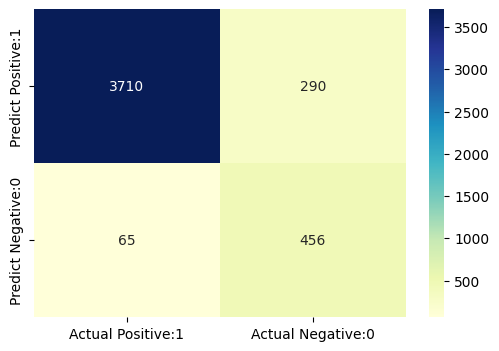

In [63]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_processed,y_pred)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [61]:
print(classification_report(y_processed, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95      4000
           1       0.61      0.88      0.72       521

    accuracy                           0.92      4521
   macro avg       0.80      0.90      0.84      4521
weighted avg       0.94      0.92      0.93      4521



The results has shown that XGBoost model generalizes reasonalbly well to unseen data, the model achieved a recall of 87.52% and precision of 61.13% with an average precision of 0.5494. Also the confusion matrix shows model successfully identified 456 out of 521 actual subscribers while missing only 65 actual susbcribers.

## Scenario 2:
#### If each contact is expensive(e.g Telemarketing), low precision is not acceptable. Unnecessary contacts are expensive. We have choose model that balances both precision-recall.

In [ ]:
thresholds = np.arange(0.40, 0.85, 0.02)
thresholds

array([0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 ,
       0.62, 0.64, 0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82,
       0.84])

In [ ]:
results_1 = []

for t in thresholds:
    y_pred = (y_prob_1 >= t).astype(int)
    precision = precision_score(y_test_processed, y_pred)
    recall = recall_score(y_test_processed, y_pred)
    f1 = f1_score(y_test_processed, y_pred)

    results_1.append([t, precision, recall, f1])

In [ ]:
results_1 = []

for t in thresholds:
    y_pred = (y_prob_1 >= t).astype(int)
    precision = precision_score(y_test_processed, y_pred)
    recall = recall_score(y_test_processed, y_pred)
    f1 = f1_score(y_test_processed, y_pred)
    
    results_1.append([t, precision, recall, f1])

threshold_df_1 = pd.DataFrame(
    results_1,
    columns=["Threshold", "Precision", "Recall", "F1"] 
)
threshold_df_1.sort_values('Precision', ascending=False).head(10)

,Threshold,Precision,Recall,F1
149,0.847,0.662695,0.452441,0.537746
148,0.844,0.658537,0.456195,0.539002
146,0.838,0.657642,0.471214,0.549034
147,0.841,0.657194,0.463079,0.543319
145,0.835,0.653184,0.474969,0.550000
144,0.832,0.646909,0.478098,0.549838
143,0.829,0.644223,0.484981,0.553374
142,0.826,0.640942,0.493742,0.557794
141,0.823,0.639044,0.501877,0.562215
140,0.820,0.636435,0.509387,0.565867


In [ ]:
results_2 = []

for t in thresholds:
    y_pred = (y_prob_2 >= t).astype(int)
    precision = precision_score(y_test_processed, y_pred)
    recall = recall_score(y_test_processed, y_pred)
    f1 = f1_score(y_test_processed, y_pred)

    results_2.append([t, precision, recall, f1])

threshold_df_2 = pd.DataFrame(
    results_2,
    columns=["Threshold", "Precision", "Recall", "F1"]
)
threshold_df_2.sort_values('Precision', ascending=False).head(10)

,Threshold,Precision,Recall,F1
147,0.841,0.655556,0.479975,0.554191
149,0.847,0.653779,0.465582,0.543860
148,0.844,0.652513,0.471214,0.547238
146,0.838,0.651477,0.483104,0.554797
145,0.835,0.650332,0.489987,0.558887
144,0.832,0.647252,0.493742,0.560170
142,0.826,0.645833,0.504380,0.566409
143,0.829,0.645292,0.497497,0.561837
141,0.823,0.641107,0.507509,0.566539
140,0.820,0.639969,0.515019,0.570735


Tuning threshold is not improving Precision much, we need to use oversampling or undersampling technqiues. Since, we have large dataset undersampling Majority class would result in loss of information as we have many categorical feature this might result in exclusion of some of the classes of categorical features. So we should focused on Oversampling techniques.

1. SMOTE
2. SMOTENC
3. BalancedRandomForest
4. 

1. Oversampling Technique
2. Train all models
3. Filter best models
4. Hyperparamter Tuning(RandomizedSearchCV)
5. Fit best model
6. Performance Assessment and Improvement(Using threshold tuning)

In [ ]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Debt(Home/Personal)
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,yes
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,yes


In [ ]:
lt = []
for i,j in enumerate(list(X_train.columns)):
    if X_train[j].dtype == 'O':
        lt.append(i)

print(lt)

[1, 2, 3, 4, 6, 7, 8, 10, 15, 16]


#### SMOTENC

In [ ]:
from imblearn.over_sampling import SMOTENC  

smote_nc = SMOTENC(categorical_features = [1, 2, 3, 4, 6, 7, 8, 10, 15, 16], random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

In [ ]:
y_train.shape, y_resampled.shape

((31647,), (55912,))

In [ ]:
X_train_resampled = pipeline.fit_transform(X_resampled)
X_test_resampled = pipeline.transform(X_test)
y_train_resampled = le.fit_transform(y_resampled)
y_test_resampled = le.transform(y_test)

In [ ]:
X_train_resampled.shape, y_train_resampled.shape

((55912, 44), (55912,))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test_resampled)
print(classification_report(y_test_resampled, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91     11966
           1       0.42      0.75      0.54      1598

    accuracy                           0.85     13564
   macro avg       0.69      0.80      0.72     13564
weighted avg       0.90      0.85      0.87     13564



In [ ]:
models = {
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier(),
    'SVC': SVC(),
    'lightgbm': LGBMClassifier(),
    'XGBoost': XGBClassifier()
}

summary = {'model':[], 'train_accuracy':[], 'test_accuracy':[], 'train_precision':[], 'test_precision':[], 'train_recall':[], 'test_recall':[], 'train_f1':[], 'test_f1':[]}

for i in range(len(models)):

    model = list(models.values())[i]
    model_name = list(models.keys())[i]
    summary['model'].append(model_name)

    # Train Model
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test_resampled)

    # Evaluate Train Set
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(y_train_resampled, y_train_pred)
    summary['train_accuracy'].append(train_accuracy)
    summary['train_precision'].append(train_precision)
    summary['train_recall'].append(train_recall)
    summary['train_f1'].append(train_f1)

    # Evaluate Test Set
    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(y_test_resampled, y_test_pred)
    summary['test_accuracy'].append(test_accuracy)
    summary['test_precision'].append(test_precision)
    summary['test_recall'].append(test_recall)
    summary['test_f1'].append(test_f1)

    print(list(models.keys())[i])

    print("Model Performance on Train Set: ")
    print("- Accuracy: {:.4f}".format(train_accuracy))
    print("- Precision: {:.4f}".format(train_precision))
    print("- Recall: {:.4f}".format(train_recall))
    print("- f1: {:.4f}".format(train_f1))

    print('----------------------------------')

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(test_accuracy))
    print("- Precision: {:.4f}".format(test_precision))
    print("- Recall: {:.4f}".format(test_recall))
    print("- F1 Score: {:.4f}".format(test_f1))

    print('=' * 35)
    print('\n')
    

DecisionTree
Model Performance on Train Set: 
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- f1: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8494
- Precision: 0.4054
- Recall: 0.5964
- F1 Score: 0.4827


RandomForest
Model Performance on Train Set: 
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- f1: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8854
- Precision: 0.5099
- Recall: 0.7078
- F1 Score: 0.5928


SVC
Model Performance on Train Set: 
- Accuracy: 0.8672
- Precision: 0.8381
- Recall: 0.9102
- f1: 0.8726
----------------------------------
Model performance for Test set
- Accuracy: 0.8208
- Precision: 0.3777
- Recall: 0.8041
- F1 Score: 0.5140


[LightGBM] [Info] Number of positive: 27956, number of negative: 27956
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004342 seconds.
You can set `force_row_wise=true` to remove the overhead.
An

In [ ]:
summary_df = pd.DataFrame(summary)
summary_df

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
0,DecisionTree,1.000000,0.849381,1.000000,0.405359,1.000000,0.596370,1.000000,0.482654
1,RandomForest,0.999982,0.885432,0.999964,0.509919,1.000000,0.707760,0.999982,0.592767
2,SVC,0.867166,0.820849,0.838082,0.377719,0.910180,0.804130,0.872644,0.514000
3,lightgbm,0.923183,0.877027,0.904144,0.486199,0.946738,0.771589,0.924951,0.596517
4,XGBoost,0.952533,0.882483,0.939759,0.500887,0.967055,0.707134,0.953212,0.586404


In [ ]:
lgbm_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [-1, 5, 10, 15, 20],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1],
    'class_weight': [None, 'balanced']
}

xgboost_params = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0.1, 1, 3, 5, 10]
}

In [ ]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [ ]:
randomcv_models = [
    ('LightGBM', LGBMClassifier(), lgbm_params),
    ('XGBoost', XGBClassifier(), xgboost_params)
]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model_para = {}
for name, model, param in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=param, n_iter=50, cv=5, verbose=2, n_jobs=-1, scoring='precision', random_state=42)
    randomcv.fit(X_train_resampled, y_train_resampled)
    model_para[name] = randomcv.best_params_

for model_name in model_para.keys():
    print(f'------Best param for {model_name}------')
    print(model_para[model_name])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
------Best param for LightGBM------
{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 1, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 1.0, 'class_weight': 'balanced'}
------Best param for XGBoost------
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.9}


In [ ]:
model_1 = LGBMClassifier(subsample=0.6, reg_lambda=0, reg_alpha=1, num_leaves=63, n_estimators=500, min_child_samples=20, max_depth=10, learning_rate=0.2, colsample_bytree=1.0, class_weight='balanced', random_state=42)
model_1.fit(X_train_resampled, y_train_resampled)
y_pred = model_1.predict(X_test_resampled)
print('Accuracy: ', accuracy_score(y_test_resampled, y_pred))
print(classification_report(y_test_resampled, y_pred))

Accuracy:  0.8911825420230021
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     11966
           1       0.53      0.66      0.59      1598

    accuracy                           0.89     13564
   macro avg       0.74      0.79      0.76     13564
weighted avg       0.90      0.89      0.90     13564



In [ ]:
model_2 = XGBClassifier(subsample=1.0, reg_lambda=0.1, reg_alpha=1, n_estimators=700, min_child_weight=1, max_depth=10, learning_rate=0.2, gamma=0, colsample_bytree=0.9, random_state=42)
model_2.fit(X_train_resampled, y_train_resampled)
y_pred = model_2.predict(X_test_resampled)
print('Accuracy: ', accuracy_score(y_test_resampled, y_pred))
print(classification_report(y_test_resampled, y_pred))

Accuracy:  0.8937629017988794
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     11966
           1       0.54      0.64      0.59      1598

    accuracy                           0.89     13564
   macro avg       0.75      0.78      0.76     13564
weighted avg       0.90      0.89      0.90     13564



In [ ]:
from sklearn.metrics import confusion_matrix
print("LightGBM:")
print(confusion_matrix(y_test_resampled, model_1.predict(X_test_resampled)))
print()
print("XGBoost:")
print(confusion_matrix(y_test_resampled, model_2.predict(X_test_resampled)))

LightGBM:
[[11033   933]
 [  543  1055]]

XGBoost:
[[11098   868]
 [  573  1025]]


In [ ]:
from sklearn.metrics import f1_score

In [ ]:
## Threshold tuning on XGBoost
y_prob = model_2.predict_proba(X_test_resampled)[:,1]
thresholds = np.arange(0.30, 0.85, 0.009)
results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precision = precision_score(y_test_resampled, y_pred)
    recall = recall_score(y_test_resampled, y_pred)
    f1 = f1_score(y_test_resampled, y_pred)

    results.append([t, precision, recall, f1])

threshold = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)
threshold.sort_values('Precision', ascending=False).head(10)

,Threshold,Precision,Recall,F1
61,0.849,0.601709,0.440551,0.508671
59,0.831,0.598865,0.462453,0.521893
60,0.840,0.598340,0.451189,0.514449
58,0.822,0.596813,0.468711,0.525061
57,0.813,0.590240,0.476846,0.527518
56,0.804,0.588593,0.484355,0.531411
55,0.795,0.586387,0.490613,0.534242
54,0.786,0.584808,0.496245,0.536899
53,0.777,0.584180,0.503755,0.540995
52,0.768,0.581081,0.511264,0.543941


In [ ]:
y_pred = (y_prob > 0.849).astype(int)
print(confusion_matrix(y_test_resampled, y_pred))

[[11500   466]
 [  894   704]]
